In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

In [2]:
# Get CIFAR10 data
!pip install wget
import wget
import tarfile
import os

filename = "cifar-10-batches-py/data_batch_1"
if not os.path.exists(filename):
    path = "data.tar.gz"
    if not os.path.exists(path):
        wget.download("http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz", path)
    tar = tarfile.open(path, "r:gz")
    tar.extractall()
    tar.close()


## Structure of Codes

The structure of provided codes and the functionality of its containing files is shown as below:

```bash
main.ipynb # Interactive notebook, to help you understand your task
features.py # Code to calulate the HOG other image features
data.tar.gz # Downloaded tar file
cifar-10-batches-py/
    data_batch_1 #Cifar-10 Image data which we will work with
```

In [4]:
# Loading data in X and Y numpy array
# dict_classes maps Y values to its class name
import pickle

""" load single batch of cifar """
dict_classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer', 5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}
X = None
y = None
with open(filename, 'rb') as f:
    datadict = pickle.load(f, encoding='latin1')
    X = datadict['data']
    y = datadict['labels']
#    X = X.reshape(10000, 3, 32, 32).transpose(0,2,3,1).astype("float")
    X = X.reshape(10000, 3, 32, 32).transpose(0,2,3,1)
    y = np.array(y)
    
""" X is numpy array images (samples_size, X_Dim, Y_Dim, Channels), y contains its corresponding labels """

' X is numpy array images (samples_size, X_Dim, Y_Dim, Channels), y contains its corresponding labels '

### Task 1: Understand the data


In [5]:
print("answer 1: total number of samples available:")
print(X[:,1,1,1].shape)
print("\n")

print("answer 2: shape of the per image:")
print(X[1].shape)

answer 1: total number of samples available:
(10000,)


answer 2: shape of the per image:
(32, 32, 3)


<font color=blue>
total number of samples available = 10,000 samples
</font>

<font color=blue>
shape of the per image = 3 channels (Red, Green, Blue) in 32x32 (width x height) pixels
</font>

In [6]:
label_names = dict_classes
label_counts = dict(zip(*np.unique(y, return_counts=True)))
for key, value in label_counts.items():
    print('Label Counts of [{}]({}) : {}'.format(key, label_names[key].upper(), value))

Label Counts of [0](PLANE) : 1005
Label Counts of [1](CAR) : 974
Label Counts of [2](BIRD) : 1032
Label Counts of [3](CAT) : 1016
Label Counts of [4](DEER) : 999
Label Counts of [5](DOG) : 937
Label Counts of [6](FROG) : 1030
Label Counts of [7](HORSE) : 1001
Label Counts of [8](SHIP) : 1025
Label Counts of [9](TRUCK) : 981


<font color=blue>
There are 1,016 samples of "cat" label
</font>

### Task 2: Visualize the Data

For each of the categories in ``dict_classes`` visualize ``5`` images with matplotlib subplot grid

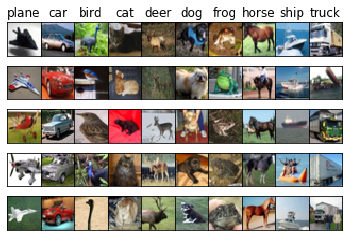

In [7]:
def visualize_images(examples_per_class):
    """Joins all 3 data's dataframe."""
    #INPUT: examples_per_class: number of examples of each class you want to show
 
    result_plane = np.where(y == 0)
    result_plane_arr = np.asarray(result_plane)

    result_car = np.where(y == 1)
    result_car_arr = np.asarray(result_car)

    result_bird = np.where(y == 2)
    result_bird_arr = np.asarray(result_bird)

    result_cat = np.where(y == 3)
    result_cat_arr = np.asarray(result_cat)

    result_deer = np.where(y == 4)
    result_deer_arr = np.asarray(result_deer)

    result_dog = np.where(y == 5)
    result_dog_arr = np.asarray(result_dog)

    result_frog = np.where(y == 6)
    result_frog_arr = np.asarray(result_frog)

    result_horse = np.where(y == 7)
    result_horse_arr = np.asarray(result_horse)

    result_ship = np.where(y == 8)
    result_ship_arr = np.asarray(result_ship)

    result_truck = np.where(y == 9)
    result_truck_arr = np.asarray(result_truck)

    fig, axs = plt.subplots(examples_per_class, 10, sharex='col', sharey='row',
                        gridspec_kw={'hspace': 0, 'wspace': 0})


    for i in range(examples_per_class):
        axs[0, 0].set_title(dict_classes[0])
        im_plane = X[result_plane_arr[0,i]]
        axs[i, 0].imshow(im_plane)
        plt.setp(axs[i, 0].get_xticklabels(), visible=False)
        plt.setp(axs[i, 0].get_yticklabels(), visible=False)
        axs[i, 0].tick_params(axis='both', which='both', length=0)

        axs[0, 1].set_title(dict_classes[1])
        im_car = X[result_car_arr[0,i]]
        axs[i, 1].imshow(im_car)
        plt.setp(axs[i, 1].get_xticklabels(), visible=False)
        plt.setp(axs[i, 1].get_yticklabels(), visible=False)
        axs[i, 1].tick_params(axis='both', which='both', length=0)
    
        axs[0, 2].set_title(dict_classes[2])
        im_bird = X[result_bird_arr[0,i]]
        axs[i, 2].imshow(im_bird)
        plt.setp(axs[i, 2].get_xticklabels(), visible=False)
        plt.setp(axs[i, 2].get_yticklabels(), visible=False)
        axs[i, 2].tick_params(axis='both', which='both', length=0)

        axs[0, 3].set_title(dict_classes[3])
        im_cat = X[result_cat_arr[0,i]]
        axs[i, 3].imshow(im_cat)
        plt.setp(axs[i, 3].get_xticklabels(), visible=False)
        plt.setp(axs[i, 3].get_yticklabels(), visible=False)
        axs[i, 3].tick_params(axis='both', which='both', length=0)
    
        axs[0, 4].set_title(dict_classes[4])
        im_deer = X[result_deer_arr[0,i]]
        axs[i, 4].imshow(im_deer)
        plt.setp(axs[i, 4].get_xticklabels(), visible=False)
        plt.setp(axs[i, 4].get_yticklabels(), visible=False)
        axs[i, 4].tick_params(axis='both', which='both', length=0)
    
        axs[0, 5].set_title(dict_classes[5])
        im_dog = X[result_dog_arr[0,i]]
        axs[i, 5].imshow(im_dog)
        plt.setp(axs[i, 5].get_xticklabels(), visible=False)
        plt.setp(axs[i, 5].get_yticklabels(), visible=False)
        axs[i, 5].tick_params(axis='both', which='both', length=0)
    
        axs[0, 6].set_title(dict_classes[6])
        im_frog = X[result_frog_arr[0,i]]
        axs[i, 6].imshow(im_frog)
        plt.setp(axs[i, 6].get_xticklabels(), visible=False)
        plt.setp(axs[i, 6].get_yticklabels(), visible=False)
        axs[i, 6].tick_params(axis='both', which='both', length=0)
    
        axs[0, 7].set_title(dict_classes[7])
        im_horse = X[result_horse_arr[0,i]]
        axs[i, 7].imshow(im_horse)
        plt.setp(axs[i, 7].get_xticklabels(), visible=False)
        plt.setp(axs[i, 7].get_yticklabels(), visible=False)
        axs[i, 7].tick_params(axis='both', which='both', length=0)

        axs[0, 8].set_title(dict_classes[8])
        im_ship = X[result_ship_arr[0,i]]
        axs[i, 8].imshow(im_ship)
        plt.setp(axs[i, 8].get_xticklabels(), visible=False)
        plt.setp(axs[i, 8].get_yticklabels(), visible=False)
        axs[i, 8].tick_params(axis='both', which='both', length=0)

        axs[0, 9].set_title(dict_classes[9])
        im_truck = X[result_truck_arr[0,i]]
        axs[i, 9].imshow(im_truck)
        plt.setp(axs[i, 9].get_xticklabels(), visible=False)
        plt.setp(axs[i, 9].get_yticklabels(), visible=False)
        axs[i, 9].tick_params(axis='both', which='both', length=0)

 
visualize_images(5)

## Task 3: Split data into Train, Test and Validation set

- X being images and y labels of images, randomly split X, y into train, validation and test set

In [8]:
from sklearn.model_selection import train_test_split


# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   del X_val, y_val
   print('Clear previously loaded data.')
except:
   pass

def get_train_val_test(num_training, num_validation, num_test):
    # Split data and return train, test and validation splits
    # INPUT: num_training : Number of training data required
    #        num_validation : Number of validation data required
    #        num_test : Number of test data required
    # RETURN: X_train, y_train, X_val, y_val, X_test, y_test

    total_data = num_training + num_validation + num_test
    test_portion = num_test / total_data    
    X_train_and_val, X_test, y_train_and_val, y_test = train_test_split(X, y, test_size = test_portion,random_state = 0) # zero or any other integer

    total_data_for_val = num_training + num_validation
    validation_portion = num_validation / total_data_for_val
    X_train, X_val, y_train, y_val = train_test_split(X_train_and_val, y_train_and_val, test_size = validation_portion,random_state = 0) # zero or any other inte
    

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_train_val_test(8000, 1000, 1000)
print("Training dataset size", len(X_train))
print("Validation dataset size", len(X_val))
print("Test dataset size", len(X_test))

Training dataset size 8000
Validation dataset size 1000
Test dataset size 1000


## Extract Features
For each image we will compute a Histogram of Oriented Gradients (HOG) as well as a color histogram using the hue channel in HSV
color space. We form our final feature vector for each image by concatenating the HOG and color histogram feature vectors.

**Run this portion of code to get X_train_feats, X_val_feats, X_test feats. This is features of train, validation and test set from raw images. Do not change this portion of code**

In [9]:
# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train_feats
   del X_val_feats
   del X_test_feats
   print('Clear previously loaded data.')
except:
   pass
from features import *
num_color_bins = 10 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)
print("Shape of X_train_feats features", X_train_feats.shape)
print("Shape of X_val_feats features", X_val_feats.shape)
print("Shape of X_test_feats features", X_test_feats.shape)

Done extracting features for 1000 / 8000 images
Done extracting features for 2000 / 8000 images
Done extracting features for 3000 / 8000 images
Done extracting features for 4000 / 8000 images
Done extracting features for 5000 / 8000 images
Done extracting features for 6000 / 8000 images
Done extracting features for 7000 / 8000 images
Done extracting features for 8000 / 8000 images
Shape of X_train_feats features (8000, 154)
Shape of X_val_feats features (1000, 154)
Shape of X_test_feats features (1000, 154)


### Task 4: Normalize features using sklearn standardscaler
- Normalize your data using sklearn standard scalar
- Do not use validation and test set for fitting data into normalizer

In [10]:
from sklearn.preprocessing import StandardScaler


# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train_feat_norm
   del X_val_feat_norm
   del X_feat_test_norm
   print('Clear previously loaded data.')
except:
   pass

def get_normalized_features(X_train, X_val, X_test):
    # returns the normalized X_train, X_val and X_test
    # INPUT: X_train : Training data features
    #        X_val : Validation data features
    #        X_test : Test data features
    # RETURN: X_train_norm, X_val_norm, X_test_norm
    
   
    scaler = StandardScaler()
    
    X_train_norm = scaler.fit_transform(X_train)
    X_val_norm = scaler.fit_transform(X_val)
    X_test_norm = scaler.fit_transform(X_test)


    return X_train_norm, X_val_norm, X_test_norm

X_train_feat_norm, X_val_feat_norm, X_feat_test_norm = get_normalized_features(X_train_feats, X_val_feats, X_test_feats)
print("Shape of X_train_feat_norm features", X_train_feat_norm.shape)

Shape of X_train_feat_norm features (8000, 154)


### Task 5: Train the sklearn KNN to classify the images

In [11]:
%%time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

np.random.seed(0)
best_knn = None
knn_best_val = -1



################################################################################
# Use the validation set to find the best fit parameters of the KNN algorithm. #
# Save the best validation score in  knn_best_val.                             #
# Save the best trained classifer in best_knn.                                 #
################################################################################

#create new a knn model
knn2 = KNeighborsClassifier()

#create a dictionary of all values we want to test for n_neighbors
param_grid = {'n_neighbors': np.arange(1, 30)}

#use gridsearch to test all values for n_neighbors
knn_gscv = GridSearchCV(knn2, param_grid, cv=5)

#fit model to data
knn_gscv.fit(X_val_feat_norm, y_val)

#Best validation accuracy achieved during cross-validation
knn_best_val = knn_gscv.best_score_

#Parameters of best trained KNN
best_knn = knn_gscv.best_estimator_


print('Best validation accuracy achieved during cross-validation: %f' % knn_best_val)
print("Parameters of best trained KNN", best_knn.get_params())

Best validation accuracy achieved during cross-validation: 0.315000
Parameters of best trained KNN {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': 1, 'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}
Wall time: 30.4 s


### Task 6: Test results of best trained KNN

- Again define the KNN with best fitted parameters found above and fit the train data
- Use this KNN to print the test accuracy


In [12]:
# Define and train the KNN with best fitted parameters


knn_train = KNeighborsClassifier(n_neighbors = 15)
knn_train.fit(X_train_feat_norm,y_train)
test_acc_knn = knn_train.score(X_train_feat_norm, y_train)


print("Test accuracy = ", test_acc_knn * 100)


Test accuracy =  46.825



- Using the same KNN, print the classification report on the test data **(1 marks)**


In [22]:
from sklearn.metrics import classification_report

# Print Accuracy and Classification Report on test data



# get accuracy of the test data
knn_test = KNeighborsClassifier(n_neighbors = 15)
knn_test.fit(X_feat_test_norm,y_test)
test_acc_knn_testdata = knn_test.score(X_feat_test_norm, y_test)
print("Test accuracy = ",test_acc_knn_testdata * 100)

y_pred_knn = knn_test.predict(X_feat_test_norm)
class_report_knn = classification_report(y_test,y_pred_knn)


print(class_report_knn)



Test accuracy =  36.5
             precision    recall  f1-score   support

          0       0.64      0.36      0.46       107
          1       0.79      0.24      0.37        95
          2       0.32      0.26      0.29        96
          3       0.43      0.19      0.27       115
          4       0.20      0.86      0.33        84
          5       0.62      0.22      0.33        91
          6       0.27      0.49      0.35       105
          7       0.69      0.24      0.36        90
          8       0.49      0.64      0.56       117
          9       0.89      0.17      0.29       100

avg / total       0.53      0.36      0.36      1000



### TASK 7: Train the sklearn SVM to classify the images (3 marks)

In [14]:
from sklearn.svm import SVC

np.random.seed(0)
svm_best_val = -1
best_svm = None

################################################################################
# Use the validation set to find the best fit parameters of the SVM algorithm. #
# Save the best validation score in  svm_best_val.                             #
# Save the best trained classifer in best_svm.                                 #
################################################################################

from sklearn.model_selection import GridSearchCV 

# defining parameter range 
param_grid = {'C': [0.1, 1, 10, 100, 1000],  
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
              'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}  

# hyperparameter tuning
svm_gscv = GridSearchCV(SVC(), param_grid, refit = True, cv=5, verbose = 3) 
  
# fitting the model for grid search 
svm_gscv.fit(X_val_feat_norm, y_val)

# best validation accuracy achieved during cross-validation
best_val = svm_gscv.best_score_

# Parameters of best trained SVM
best_svm = svm_gscv.best_estimator_
    

print('best validation accuracy achieved during cross-validation: %f' % best_val)
print("Parameters of best trained SVM", best_svm.get_params())

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] C=0.1, gamma=1, kernel=linear ...................................
[CV]  C=0.1, gamma=1, kernel=linear, score=0.3627450980392157, total=   0.1s
[CV] C=0.1, gamma=1, kernel=linear ...................................


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s remaining:    0.0s


[CV]  C=0.1, gamma=1, kernel=linear, score=0.3399014778325123, total=   0.1s
[CV] C=0.1, gamma=1, kernel=linear ...................................


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.5s remaining:    0.0s


[CV] ....... C=0.1, gamma=1, kernel=linear, score=0.335, total=   0.1s
[CV] C=0.1, gamma=1, kernel=linear ...................................
[CV]  C=0.1, gamma=1, kernel=linear, score=0.3333333333333333, total=   0.1s
[CV] C=0.1, gamma=1, kernel=linear ...................................
[CV]  C=0.1, gamma=1, kernel=linear, score=0.4461538461538462, total=   0.1s
[CV] C=0.1, gamma=1, kernel=poly .....................................
[CV]  C=0.1, gamma=1, kernel=poly, score=0.3627450980392157, total=   0.1s
[CV] C=0.1, gamma=1, kernel=poly .....................................
[CV]  C=0.1, gamma=1, kernel=poly, score=0.3103448275862069, total=   0.2s
[CV] C=0.1, gamma=1, kernel=poly .....................................
[CV] .......... C=0.1, gamma=1, kernel=poly, score=0.28, total=   0.2s
[CV] C=0.1, gamma=1, kernel=poly .....................................
[CV]  C=0.1, gamma=1, kernel=poly, score=0.3333333333333333, total=   0.2s
[CV] C=0.1, gamma=1, kernel=poly ....................

...

[CV]  C=100, gamma=0.1, kernel=sigmoid, score=0.26262626262626265, total=   0.1s
[CV] C=100, gamma=0.1, kernel=sigmoid ................................
[CV]  C=100, gamma=0.1, kernel=sigmoid, score=0.3282051282051282, total=   0.0s
[CV] C=100, gamma=0.01, kernel=linear ................................
[CV]  C=100, gamma=0.01, kernel=linear, score=0.36764705882352944, total=   0.1s
[CV] C=100, gamma=0.01, kernel=linear ................................
[CV]  C=100, gamma=0.01, kernel=linear, score=0.33497536945812806, total=   0.1s
[CV] C=100, gamma=0.01, kernel=linear ................................
[CV] ..... C=100, gamma=0.01, kernel=linear, score=0.33, total=   0.1s
[CV] C=100, gamma=0.01, kernel=linear ................................
[CV]  C=100, gamma=0.01, kernel=linear, score=0.35858585858585856, total=   0.1s
[CV] C=100, gamma=0.01, kernel=linear ................................
[CV]  C=100, gamma=0.01, kernel=linear, score=0.4153846153846154, total=   0.1s
[CV] C=100, gamma=0

[CV]  C=100, gamma=0.0001, kernel=rbf, score=0.37373737373737376, total=   0.1s
[CV] C=100, gamma=0.0001, kernel=rbf .................................
[CV]  C=100, gamma=0.0001, kernel=rbf, score=0.4307692307692308, total=   0.2s
[CV] C=100, gamma=0.0001, kernel=sigmoid .............................
[CV]  C=100, gamma=0.0001, kernel=sigmoid, score=0.4117647058823529, total=   0.1s
[CV] C=100, gamma=0.0001, kernel=sigmoid .............................
[CV]  C=100, gamma=0.0001, kernel=sigmoid, score=0.42857142857142855, total=   0.1s
[CV] C=100, gamma=0.0001, kernel=sigmoid .............................
[CV] .. C=100, gamma=0.0001, kernel=sigmoid, score=0.41, total=   0.1s
[CV] C=100, gamma=0.0001, kernel=sigmoid .............................
[CV]  C=100, gamma=0.0001, kernel=sigmoid, score=0.4090909090909091, total=   0.1s
[CV] C=100, gamma=0.0001, kernel=sigmoid .............................
[CV]  C=100, gamma=0.0001, kernel=sigmoid, score=0.4256410256410256, total=   0.1s
[CV] C=1000

[CV]  C=1000, gamma=0.01, kernel=poly, score=0.3435897435897436, total=   0.2s
[CV] C=1000, gamma=0.01, kernel=rbf ..................................
[CV]  C=1000, gamma=0.01, kernel=rbf, score=0.39215686274509803, total=   0.2s
[CV] C=1000, gamma=0.01, kernel=rbf ..................................
[CV]  C=1000, gamma=0.01, kernel=rbf, score=0.43349753694581283, total=   0.2s
[CV] C=1000, gamma=0.01, kernel=rbf ..................................
[CV] ....... C=1000, gamma=0.01, kernel=rbf, score=0.41, total=   0.2s
[CV] C=1000, gamma=0.01, kernel=rbf ..................................
[CV]  C=1000, gamma=0.01, kernel=rbf, score=0.40404040404040403, total=   0.2s
[CV] C=1000, gamma=0.01, kernel=rbf ..................................
[CV]  C=1000, gamma=0.01, kernel=rbf, score=0.47692307692307695, total=   0.2s
[CV] C=1000, gamma=0.01, kernel=sigmoid ..............................
[CV]  C=1000, gamma=0.01, kernel=sigmoid, score=0.29411764705882354, total=   0.0s
[CV] C=1000, gamma=0.01, 

[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  2.9min finished


best validation accuracy achieved during cross-validation: 0.423000
Parameters of best trained SVM {'C': 10, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


### Task 8: Test results of best trained SVM

- Again define the SVM with best fitted parameters found above and fit the train data 
- Use this SVM to print the test accuracy 


In [42]:
svm_train = SVC(kernel='rbf', gamma=0.01)
svm_train.fit(X_train_feat_norm,y_train)
test_acc_svm = svm_train.score(X_train_feat_norm, y_train)

print("Test accuracy = ", test_acc_svm * 100)


Test accuracy =  89.375



- Using the same SVM, print the classification report on the test data **(1 marks)**


In [40]:
from sklearn.metrics import classification_report


svm_test = SVC(kernel='rbf', gamma=0.01)
svm_test.fit(X_feat_test_norm,y_test)

y_pred_svm = svm_test.predict(X_feat_test_norm)
class_report_svm = classification_report(y_test,y_pred_svm)

test_acc_svm_testdata = svm_test.score(X_feat_test_norm, y_test)
print("Test accuracy = ", test_acc_svm_testdata * 100)

print(class_report_svm)


Test accuracy =  96.2
             precision    recall  f1-score   support

          0       0.94      0.96      0.95       107
          1       1.00      0.98      0.99        95
          2       0.96      0.93      0.94        96
          3       0.96      0.93      0.95       115
          4       0.88      0.99      0.93        84
          5       0.99      0.91      0.95        91
          6       0.94      0.98      0.96       105
          7       1.00      0.97      0.98        90
          8       0.96      0.98      0.97       117
          9       1.00      0.99      0.99       100

avg / total       0.96      0.96      0.96      1000



### Task 9: Visualize wrong predictions 

- An important way to gain intuition about how the algorithm works is to visualize the mistakes that it makes. In this visualization, we show examples of images that are misclassified by our current system. The first column shows images that our system labeled as "plane" but whose true label is something other than "plane", similarly for 2nd column system visualized as "car" but not car and so on , and so forth. If some classes do not have any misclassified labels, skip the classes.



## MODEL = SVM ##

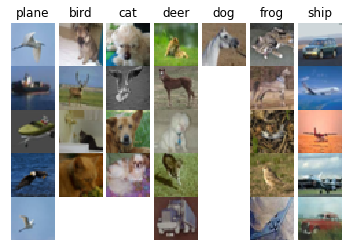

In [37]:
def visualize_negative_classified_images(examples_per_class):
    """Joins all 3 data's dataframe."""
    #INPUT: examples_per_class: number of examples of each class you want to show
    plane_pred = []
    car_pred = []
    bird_pred = []
    cat_pred = []
    deer_pred = []
    dog_pred = []
    frog_pred = []
    horse_pred = []
    ship_pred = []
    truck_pred = []

    list_compare = []

    for count,test,pred in zip(range(len(X_test)),y_test, y_pred_svm):
        if(test != pred):
            list_compare.append(count) 
        
    list_compare_arr = np.asarray(list_compare)

    prediction = y_pred_svm[list_compare_arr]


    for position,object_pred in zip(list_compare_arr,prediction):
        if object_pred == 0:
            plane_pred.append(position)
        elif object_pred == 1:
            car_pred.append(position)
        elif object_pred == 2:
            bird_pred.append(position)
        elif object_pred == 3:
            cat_pred.append(position)
        elif object_pred == 4:
            deer_pred.append(position)
        elif object_pred == 5:
            dog_pred.append(position)
        elif object_pred == 6:
            frog_pred.append(position)
        elif object_pred == 7:
            horse_pred.append(position)
        elif object_pred == 8:
            ship_pred.append(position)
        elif object_pred == 9:
            truck_pred.append(position)
        
# check each category if there's any wrong prediction
    counter = 0

    plane_pred_arr = np.asarray(plane_pred)
    plane_pred_count = len(plane_pred_arr)
    if plane_pred_count > 0:
        counter = counter + 1

    car_pred_arr = np.asarray(car_pred)
    car_pred_count = len(car_pred_arr)
    if car_pred_count > 0:
        counter = counter + 1

    bird_pred_arr = np.asarray(bird_pred)
    bird_pred_count = len(bird_pred_arr)
    if bird_pred_count > 0:
        counter = counter + 1
    
    cat_pred_arr = np.asarray(cat_pred)
    cat_pred_count = len(cat_pred_arr)
    if cat_pred_count > 0:
        counter = counter + 1    

    deer_pred_arr = np.asarray(deer_pred)
    deer_pred_count = len(deer_pred_arr)
    if deer_pred_count > 0:
        counter = counter + 1 
    
    dog_pred_arr = np.asarray(dog_pred)
    dog_pred_count = len(dog_pred_arr)
    if dog_pred_count > 0:
        counter = counter + 1 
    
    frog_pred_arr = np.asarray(frog_pred)
    frog_pred_count = len(frog_pred_arr)
    if frog_pred_count > 0:
        counter = counter + 1 
    
    horse_pred_arr = np.asarray(horse_pred)
    horse_pred_count = len(horse_pred_arr)
    if horse_pred_count > 0:
        counter = counter + 1 
    
    ship_pred_arr = np.asarray(ship_pred)
    ship_pred_count = len(ship_pred_arr)
    if ship_pred_count > 0:
        counter = counter + 1 
    
    truck_pred_arr = np.asarray(truck_pred)
    truck_pred_count = len(truck_pred_arr)
    if truck_pred_count > 0:
        counter = counter + 1 


    grid = plt.GridSpec(examples_per_class, counter, wspace=0, hspace=0)


    grid_counter = 0
    if plane_pred_count > 0:    
        grid_counter = grid_counter
        if plane_pred_count > examples_per_class:
            plane_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[0]).imshow(X_test[plane_pred_arr[0]])
        plt.axis('off')  
        for i in range(1, plane_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[plane_pred_arr[i]])
            plt.axis('off')
    
   
    if car_pred_count > 0: 
        if plane_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if car_pred_count > examples_per_class:
            car_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[1]).imshow(X_test[car_pred_arr[0]])
        plt.axis('off')  
        for i in range(1, car_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[car_pred_arr[i]])
            plt.axis('off')
       
    
    if bird_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if bird_pred_count > examples_per_class:
            bird_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[2]).imshow(X_test[bird_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, bird_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[bird_pred_arr[i]])
            plt.axis('off')


    if cat_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if cat_pred_count > examples_per_class:
            cat_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[3]).imshow(X_test[cat_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, cat_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[cat_pred_arr[i]])
            plt.axis('off')      
        
        
    if deer_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if deer_pred_count > examples_per_class:
            deer_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[4]).imshow(X_test[deer_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, deer_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[deer_pred_arr[i]])
            plt.axis('off')  
        
        
    if dog_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0 and deer_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if dog_pred_count > examples_per_class:
            dog_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[5]).imshow(X_test[dog_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, dog_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[dog_pred_arr[i]])
            plt.axis('off')   
        

    if frog_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0 and deer_pred_count == 0 and dog_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if frog_pred_count > examples_per_class:
            frog_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[6]).imshow(X_test[frog_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, frog_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[frog_pred_arr[i]])
            plt.axis('off')  
        
        
    if horse_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0 and deer_pred_count == 0 and dog_pred_count == 0 and frog_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if horse_pred_count > examples_per_class:
            horse_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[7]).imshow(X_test[horse_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, horse_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[horse_pred_arr[i]])
            plt.axis('off')  
        
        
    if ship_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0 and deer_pred_count == 0 and dog_pred_count == 0 and frog_pred_count == 0 and horse_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if ship_pred_count > examples_per_class:
            ship_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[8]).imshow(X_test[ship_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, ship_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[ship_pred_arr[i]])
            plt.axis('off')    
        
        
    if truck_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0 and deer_pred_count == 0 and dog_pred_count == 0 and frog_pred_count == 0 and horse_pred_count == 0 and ship_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if truck_pred_count > examples_per_class:
            truck_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[9]).imshow(X_test[truck_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, truck_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[truck_pred_arr[i]])
            plt.axis('off')


    
    
visualize_negative_classified_images(5)

## MODEL = KNN ##

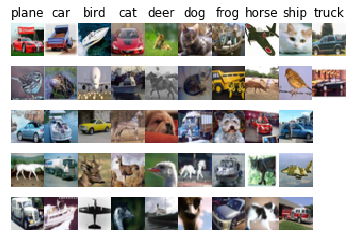

In [38]:
def visualize_negative_classified_images(examples_per_class):
    """Joins all 3 data's dataframe."""
    #INPUT: examples_per_class: number of examples of each class we want to show
    plane_pred = []
    car_pred = []
    bird_pred = []
    cat_pred = []
    deer_pred = []
    dog_pred = []
    frog_pred = []
    horse_pred = []
    ship_pred = []
    truck_pred = []

    list_compare = []

    for count,test,pred in zip(range(len(X_test)),y_test, y_pred_knn):
        if(test != pred):
            list_compare.append(count) 
        
    list_compare_arr = np.asarray(list_compare)

    prediction = y_pred_knn[list_compare_arr]


    for position,object_pred in zip(list_compare_arr,prediction):
        if object_pred == 0:
            plane_pred.append(position)
        elif object_pred == 1:
            car_pred.append(position)
        elif object_pred == 2:
            bird_pred.append(position)
        elif object_pred == 3:
            cat_pred.append(position)
        elif object_pred == 4:
            deer_pred.append(position)
        elif object_pred == 5:
            dog_pred.append(position)
        elif object_pred == 6:
            frog_pred.append(position)
        elif object_pred == 7:
            horse_pred.append(position)
        elif object_pred == 8:
            ship_pred.append(position)
        elif object_pred == 9:
            truck_pred.append(position)
        
# check each category if there's any wrong prediction
    counter = 0

    plane_pred_arr = np.asarray(plane_pred)
    plane_pred_count = len(plane_pred_arr)
    if plane_pred_count > 0:
        counter = counter + 1

    car_pred_arr = np.asarray(car_pred)
    car_pred_count = len(car_pred_arr)
    if car_pred_count > 0:
        counter = counter + 1

    bird_pred_arr = np.asarray(bird_pred)
    bird_pred_count = len(bird_pred_arr)
    if bird_pred_count > 0:
        counter = counter + 1
    
    cat_pred_arr = np.asarray(cat_pred)
    cat_pred_count = len(cat_pred_arr)
    if cat_pred_count > 0:
        counter = counter + 1    

    deer_pred_arr = np.asarray(deer_pred)
    deer_pred_count = len(deer_pred_arr)
    if deer_pred_count > 0:
        counter = counter + 1 
    
    dog_pred_arr = np.asarray(dog_pred)
    dog_pred_count = len(dog_pred_arr)
    if dog_pred_count > 0:
        counter = counter + 1 
    
    frog_pred_arr = np.asarray(frog_pred)
    frog_pred_count = len(frog_pred_arr)
    if frog_pred_count > 0:
        counter = counter + 1 
    
    horse_pred_arr = np.asarray(horse_pred)
    horse_pred_count = len(horse_pred_arr)
    if horse_pred_count > 0:
        counter = counter + 1 
    
    ship_pred_arr = np.asarray(ship_pred)
    ship_pred_count = len(ship_pred_arr)
    if ship_pred_count > 0:
        counter = counter + 1 
    
    truck_pred_arr = np.asarray(truck_pred)
    truck_pred_count = len(truck_pred_arr)
    if truck_pred_count > 0:
        counter = counter + 1 


    grid = plt.GridSpec(examples_per_class, counter, wspace=0, hspace=0)

    

    grid_counter = 0
    if plane_pred_count > 0:    
        grid_counter = grid_counter
        if plane_pred_count > examples_per_class:
            plane_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[0]).imshow(X_test[plane_pred_arr[0]])
        plt.axis('off')  
        for i in range(1, plane_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[plane_pred_arr[i]])
            plt.axis('off')
    
   
    if car_pred_count > 0: 
        if plane_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if car_pred_count > examples_per_class:
            car_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[1]).imshow(X_test[car_pred_arr[0]])
        plt.axis('off')  
        for i in range(1, car_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[car_pred_arr[i]])
            plt.axis('off')
       
    
    if bird_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if bird_pred_count > examples_per_class:
            bird_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[2]).imshow(X_test[bird_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, bird_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[bird_pred_arr[i]])
            plt.axis('off')


    if cat_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if cat_pred_count > examples_per_class:
            cat_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[3]).imshow(X_test[cat_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, cat_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[cat_pred_arr[i]])
            plt.axis('off')      
        
        
    if deer_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if deer_pred_count > examples_per_class:
            deer_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[4]).imshow(X_test[deer_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, deer_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[deer_pred_arr[i]])
            plt.axis('off')  
        
        
    if dog_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0 and deer_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if dog_pred_count > examples_per_class:
            dog_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[5]).imshow(X_test[dog_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, dog_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[dog_pred_arr[i]])
            plt.axis('off')   
        

    if frog_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0 and deer_pred_count == 0 and dog_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if frog_pred_count > examples_per_class:
            frog_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[6]).imshow(X_test[frog_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, frog_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[frog_pred_arr[i]])
            plt.axis('off')  
        
        
    if horse_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0 and deer_pred_count == 0 and dog_pred_count == 0 and frog_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if horse_pred_count > examples_per_class:
            horse_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[7]).imshow(X_test[horse_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, horse_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[horse_pred_arr[i]])
            plt.axis('off')  
        
        
    if ship_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0 and deer_pred_count == 0 and dog_pred_count == 0 and frog_pred_count == 0 and horse_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if ship_pred_count > examples_per_class:
            ship_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[8]).imshow(X_test[ship_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, ship_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[ship_pred_arr[i]])
            plt.axis('off')    
        
        
    if truck_pred_count > 0: 
        if plane_pred_count == 0 and car_pred_count == 0 and bird_pred_count == 0 and cat_pred_count  == 0 and deer_pred_count == 0 and dog_pred_count == 0 and frog_pred_count == 0 and horse_pred_count == 0 and ship_pred_count == 0:
            grid_counter = 0
        else:
            grid_counter = grid_counter + 1
        if truck_pred_count > examples_per_class:
            truck_pred_count = examples_per_class
        plt.subplot(grid[0,grid_counter], xticklabels=[], yticklabels=[], title=dict_classes[9]).imshow(X_test[truck_pred_arr[0]])
        plt.axis('off')          
        for i in range(1, truck_pred_count):  
            plt.subplot(grid[i,grid_counter],xticklabels=[],yticklabels=[]).imshow(X_test[truck_pred_arr[i]])
            plt.axis('off')


    
    
visualize_negative_classified_images(5)

### Task 10: Finding on the misclassification results

<font color=blue>
<br>
For misclassification result from SVM model: 
<br>
It is found that out of 1,000 objects in test data, 38 objects are not classified correctly by the model. Based on visualization of SVM model above, the misclassified objects look similar with the test data. For example is for class plane, some birds with the spreading wings are misclassified into this class. Another example is for class cat, some dogs are misclassified into this class. This misclassification looks quite make sense.
<br>
<br>
For misclassification result from KNN model: 
<br>
It is found that out of 1,000 objects in test data, 635 objects are not classified correctly by the model. This means that more than 50% objects are misclassifed by the model. Based on the visualization of KNN model above, the misclassification does not make sense for some classes. For example is for class Cat and Frog, where a car is misclassified into these classes. Another example is class Ship, where a cat and a bird misclassified into it. These misclasified objects do not have similarities at all with the label.
</font>

### Number of true and false predictions using SVM model ###

In [20]:
true_preds = [(x,y) for (x,y,p) in zip(X_feat_test_norm, y_test, y_pred_svm) if y == p]
false_preds = [(x,y,p) for (x,y,p) in zip(X_feat_test_norm, y_test, y_pred_svm) if y != p]
print("Number of true predictions: ", len(true_preds))
print("Number of false predictions:", len(false_preds))

Number of true predictions:  962
Number of false predictions: 38


### Number of true and false predictions using KNN model ###

In [23]:
true_preds = [(x,y) for (x,y,p) in zip(X_feat_test_norm, y_test, y_pred_knn) if y == p]
false_preds = [(x,y,p) for (x,y,p) in zip(X_feat_test_norm, y_test, y_pred_knn) if y != p]
print("Number of true predictions: ", len(true_preds))
print("Number of false predictions:", len(false_preds))

Number of true predictions:  365
Number of false predictions: 635
